#ДЗ 7

##Бганцова Полина, Б06-305

**Данные:** рак лёгкого (LuC) — Responders (R) vs Non-Responders (NR)

## **Часть 1. DESeq2 анализ**
### **1. Введение**
**Цель:** выявить гены, дифференциально экспрессированные между Responders и Non-Responders у пациентов с раком лёгкого, получающих иммунотерапию.  
**Данные:**  
- `raw_counts_ici_samples.tsv` — матрица counts (гены × образцы LuC)  
- `meta_responses.tsv` — метаданные (R / NR)  
**Метод:** DESeq2 (отрицательное биномиальное распределение).

### **2. PCA и удаление выбросов**
На первом этапе проведён PCA на основе log2-трансформированных counts.  




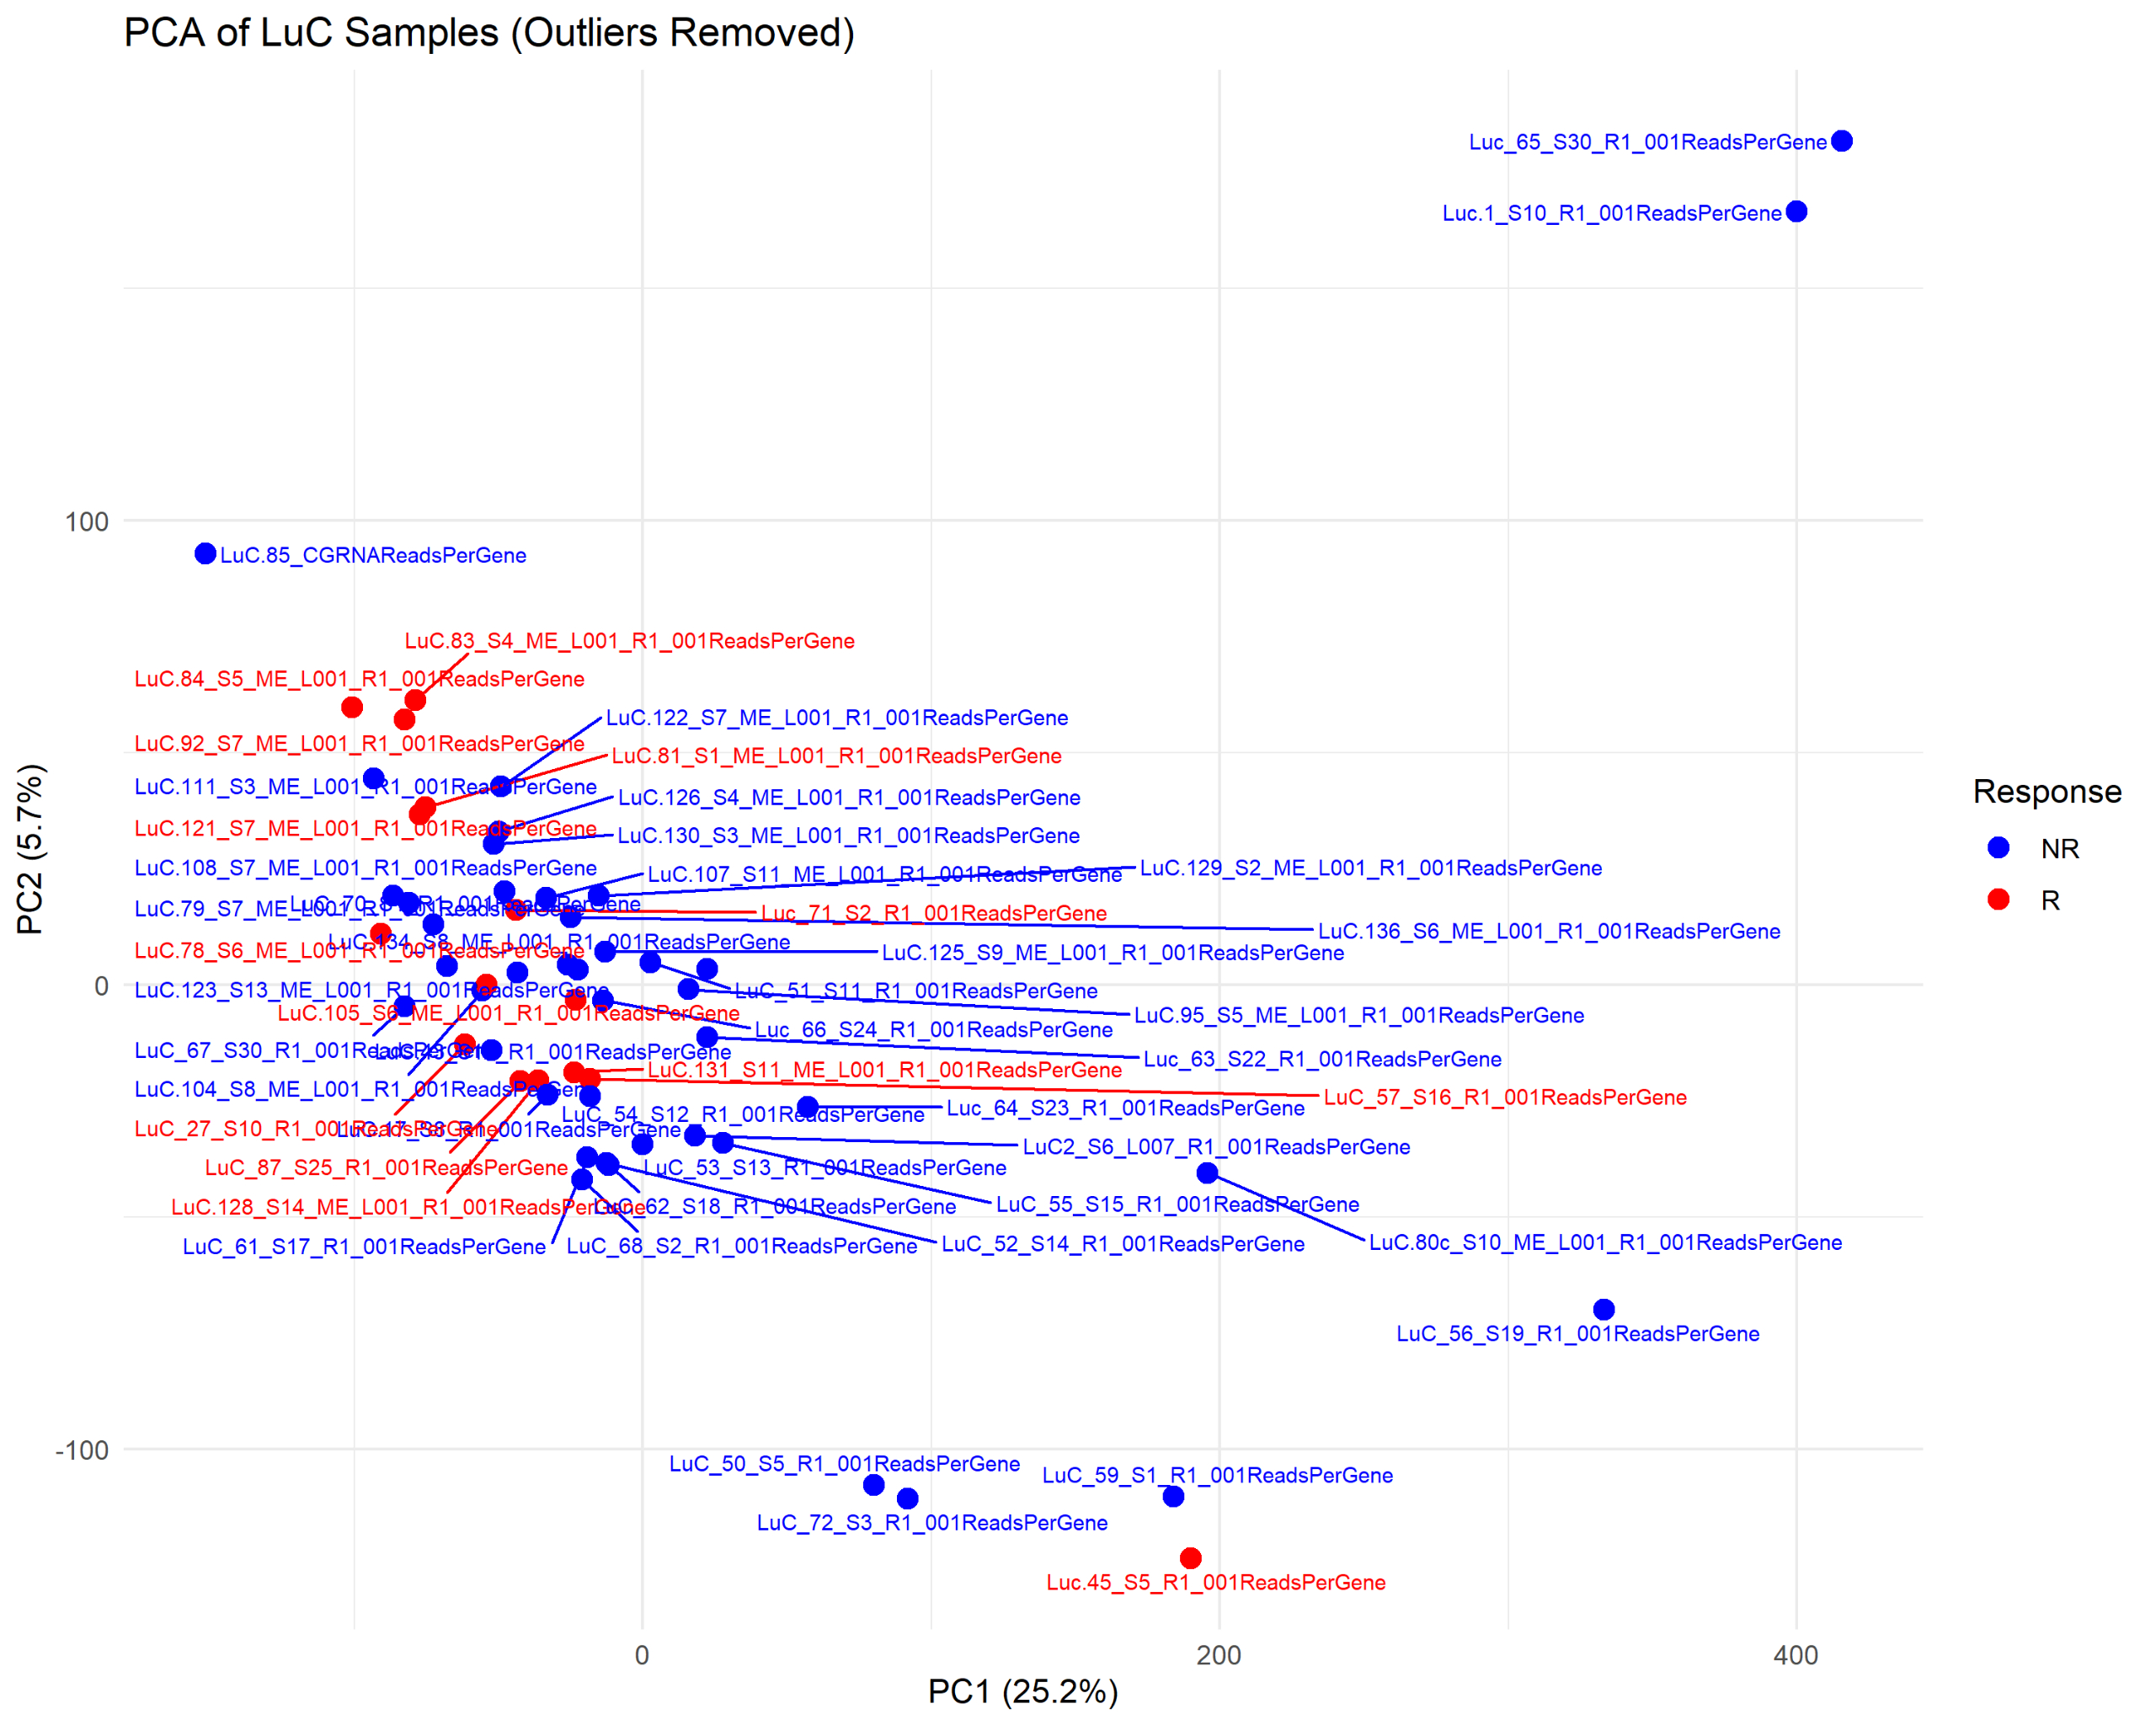

**Результаты PCA:**  
- PC1 объясняет **25.2%** дисперсии  
- PC2 объясняет **5.7%** дисперсии  
- Первые две главные компоненты вместе объясняют **30.9%** общей вариабельности данных.


Проценты дисперсии показывают, какую долю информации (изменчивости) в данных «захватила» каждая главная компонента.  
- **PC1 = 25.2%** — это самый сильный источник различий между образцами. Он отражает, например, разделение клеточных линий (HCT vs SW vs R1).  
- **PC2 = 5.7%** — второй по значимости источник вариации, он может отражать различия внутри линий или влияние менее выраженных факторов.

**Низкий кумулятивный процент (30.9%)** означает, что для полного описания данных нужно больше двух компонент (PC3, PC4 и т.д.). Однако на практике даже 30% дисперсии достаточно для визуальной оценки выбросов и общего разделения образцов.

**Выявлены выбросы:**  
- Luc_65_S30_R1  
- Luc.1_S10_R1  
- LuC_56_S19_R1  

Эти образцы имели аномально высокие значения PC1 (>300) и были исключены из дальнейшего анализа (предположительно технические артефакты).


### 3. **Clustermap LuC образцов (после удаления выбросов)**

Для визуализации сходства между образцами построена тепловая карта (clustermap) на основе корреляционной матрицы.



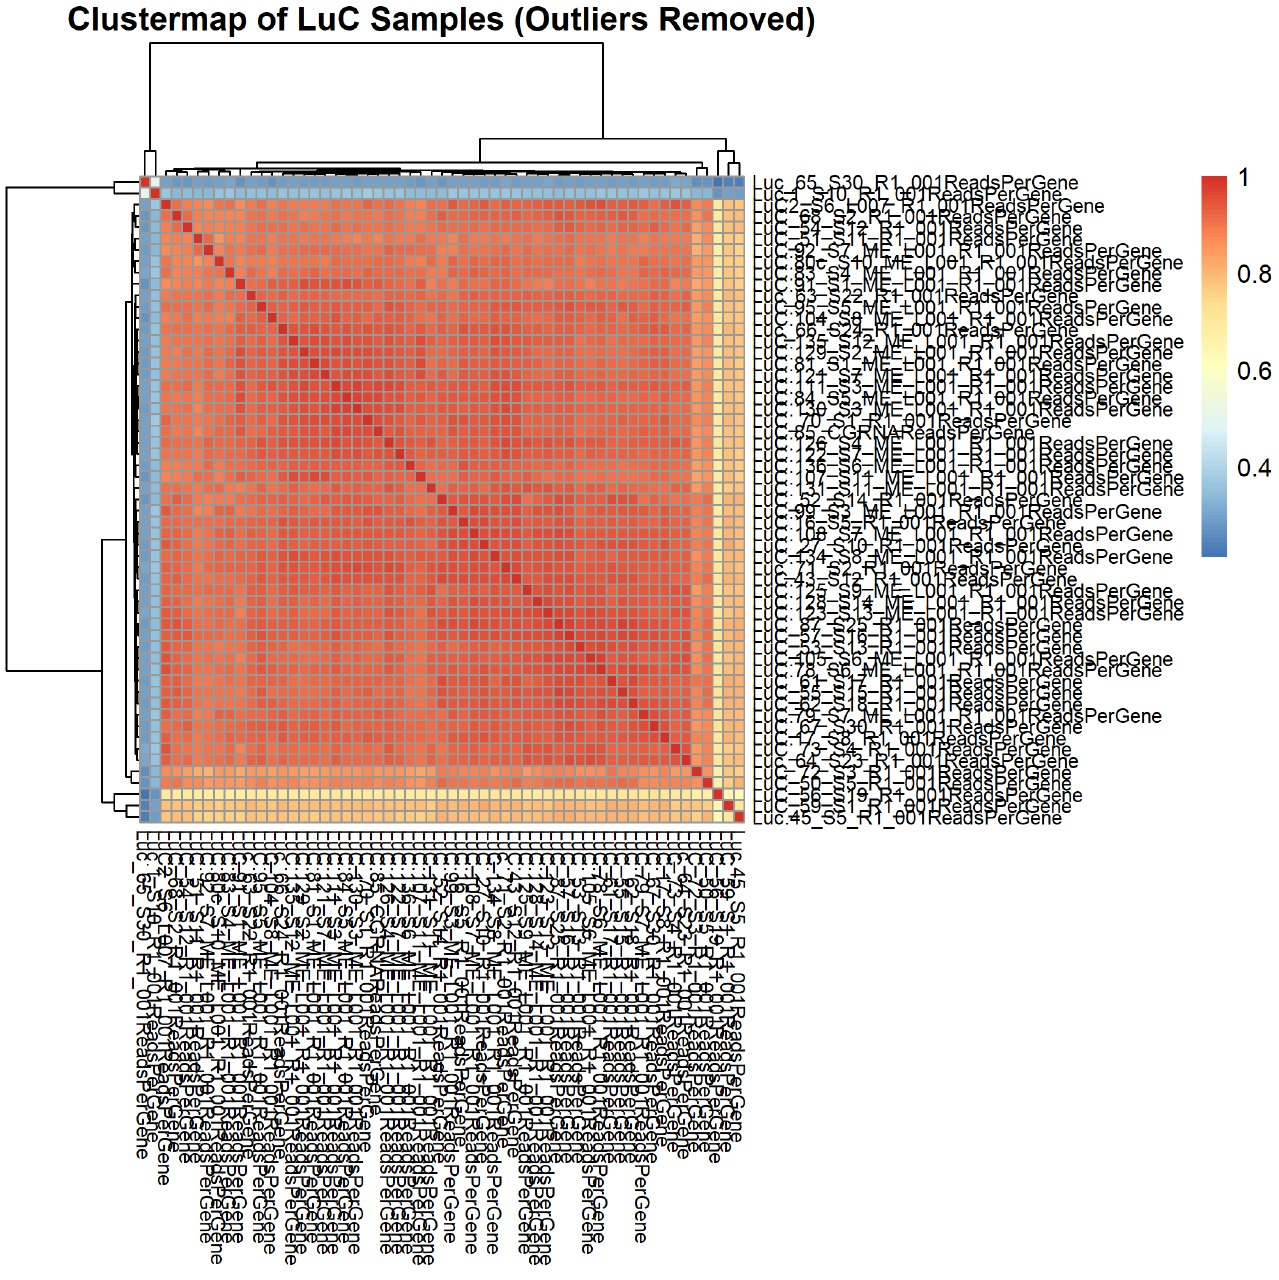

**Анализ:**  
- Корреляционная матрица симметрична, диагональные элементы равны 1.  
- Большинство образцов имеют высокую положительную корреляцию (преимущественно красные тона), что характерно для клинических образцов одного типа рака.  
- Отсутствует чёткое разделение между Responders (R) и Non-Responders (NR), что указывает на слабый дифференциальный сигнал, требующий статистической мощности DESeq2.

### **4. Анализ дифференциальной экспрессии (DESeq2)**

После удаления трёх образцов-выбросов проведён DESeq2-анализ для 57 образцов LuC (R vs NR).

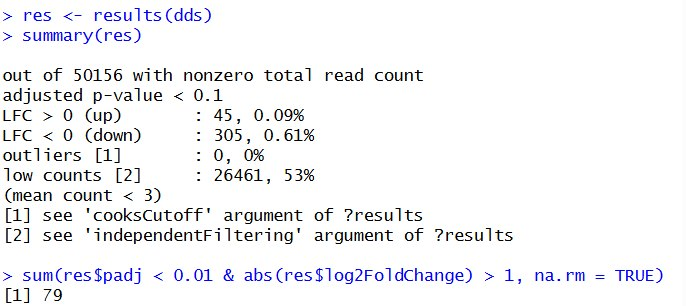

**Общая статистика:**

- Всего генов с ненулевым ридом: **50 156**
- Генов со средним count < 3 (low counts): **26 461 (53%)** – они исключены из тестирования, что нормально для RNA-seq.
- Выбросов по Cook’s distance: **0** – хорошо.

**При строгом пороге `padj < 0.01` и `|log2FC| > 1` :**
- **Количество значимых генов:** **79**
- (При мягком пороге `padj < 0.1` наблюдалось 45 повышенных и 305 пониженных генов, что указывает на преобладание подавления экспрессии у Responders.)

**Интерпретация:**  
Большинство дифференциально экспрессированных генов имеют умеренные изменения (|log2FC| от 1 до 3). При мягком пороге `padj < 0.1` видно, что пониженных генов значительно больше (305 против 45), что может указывать на общее подавление экспрессии у Responders.

### **5. Volcano plot**

Volcano plot визуализирует log2 fold change vs -log10(скорректированного p-value). Красным отмечены значимые гены (padj < 0.01, |log2FC| > 1).

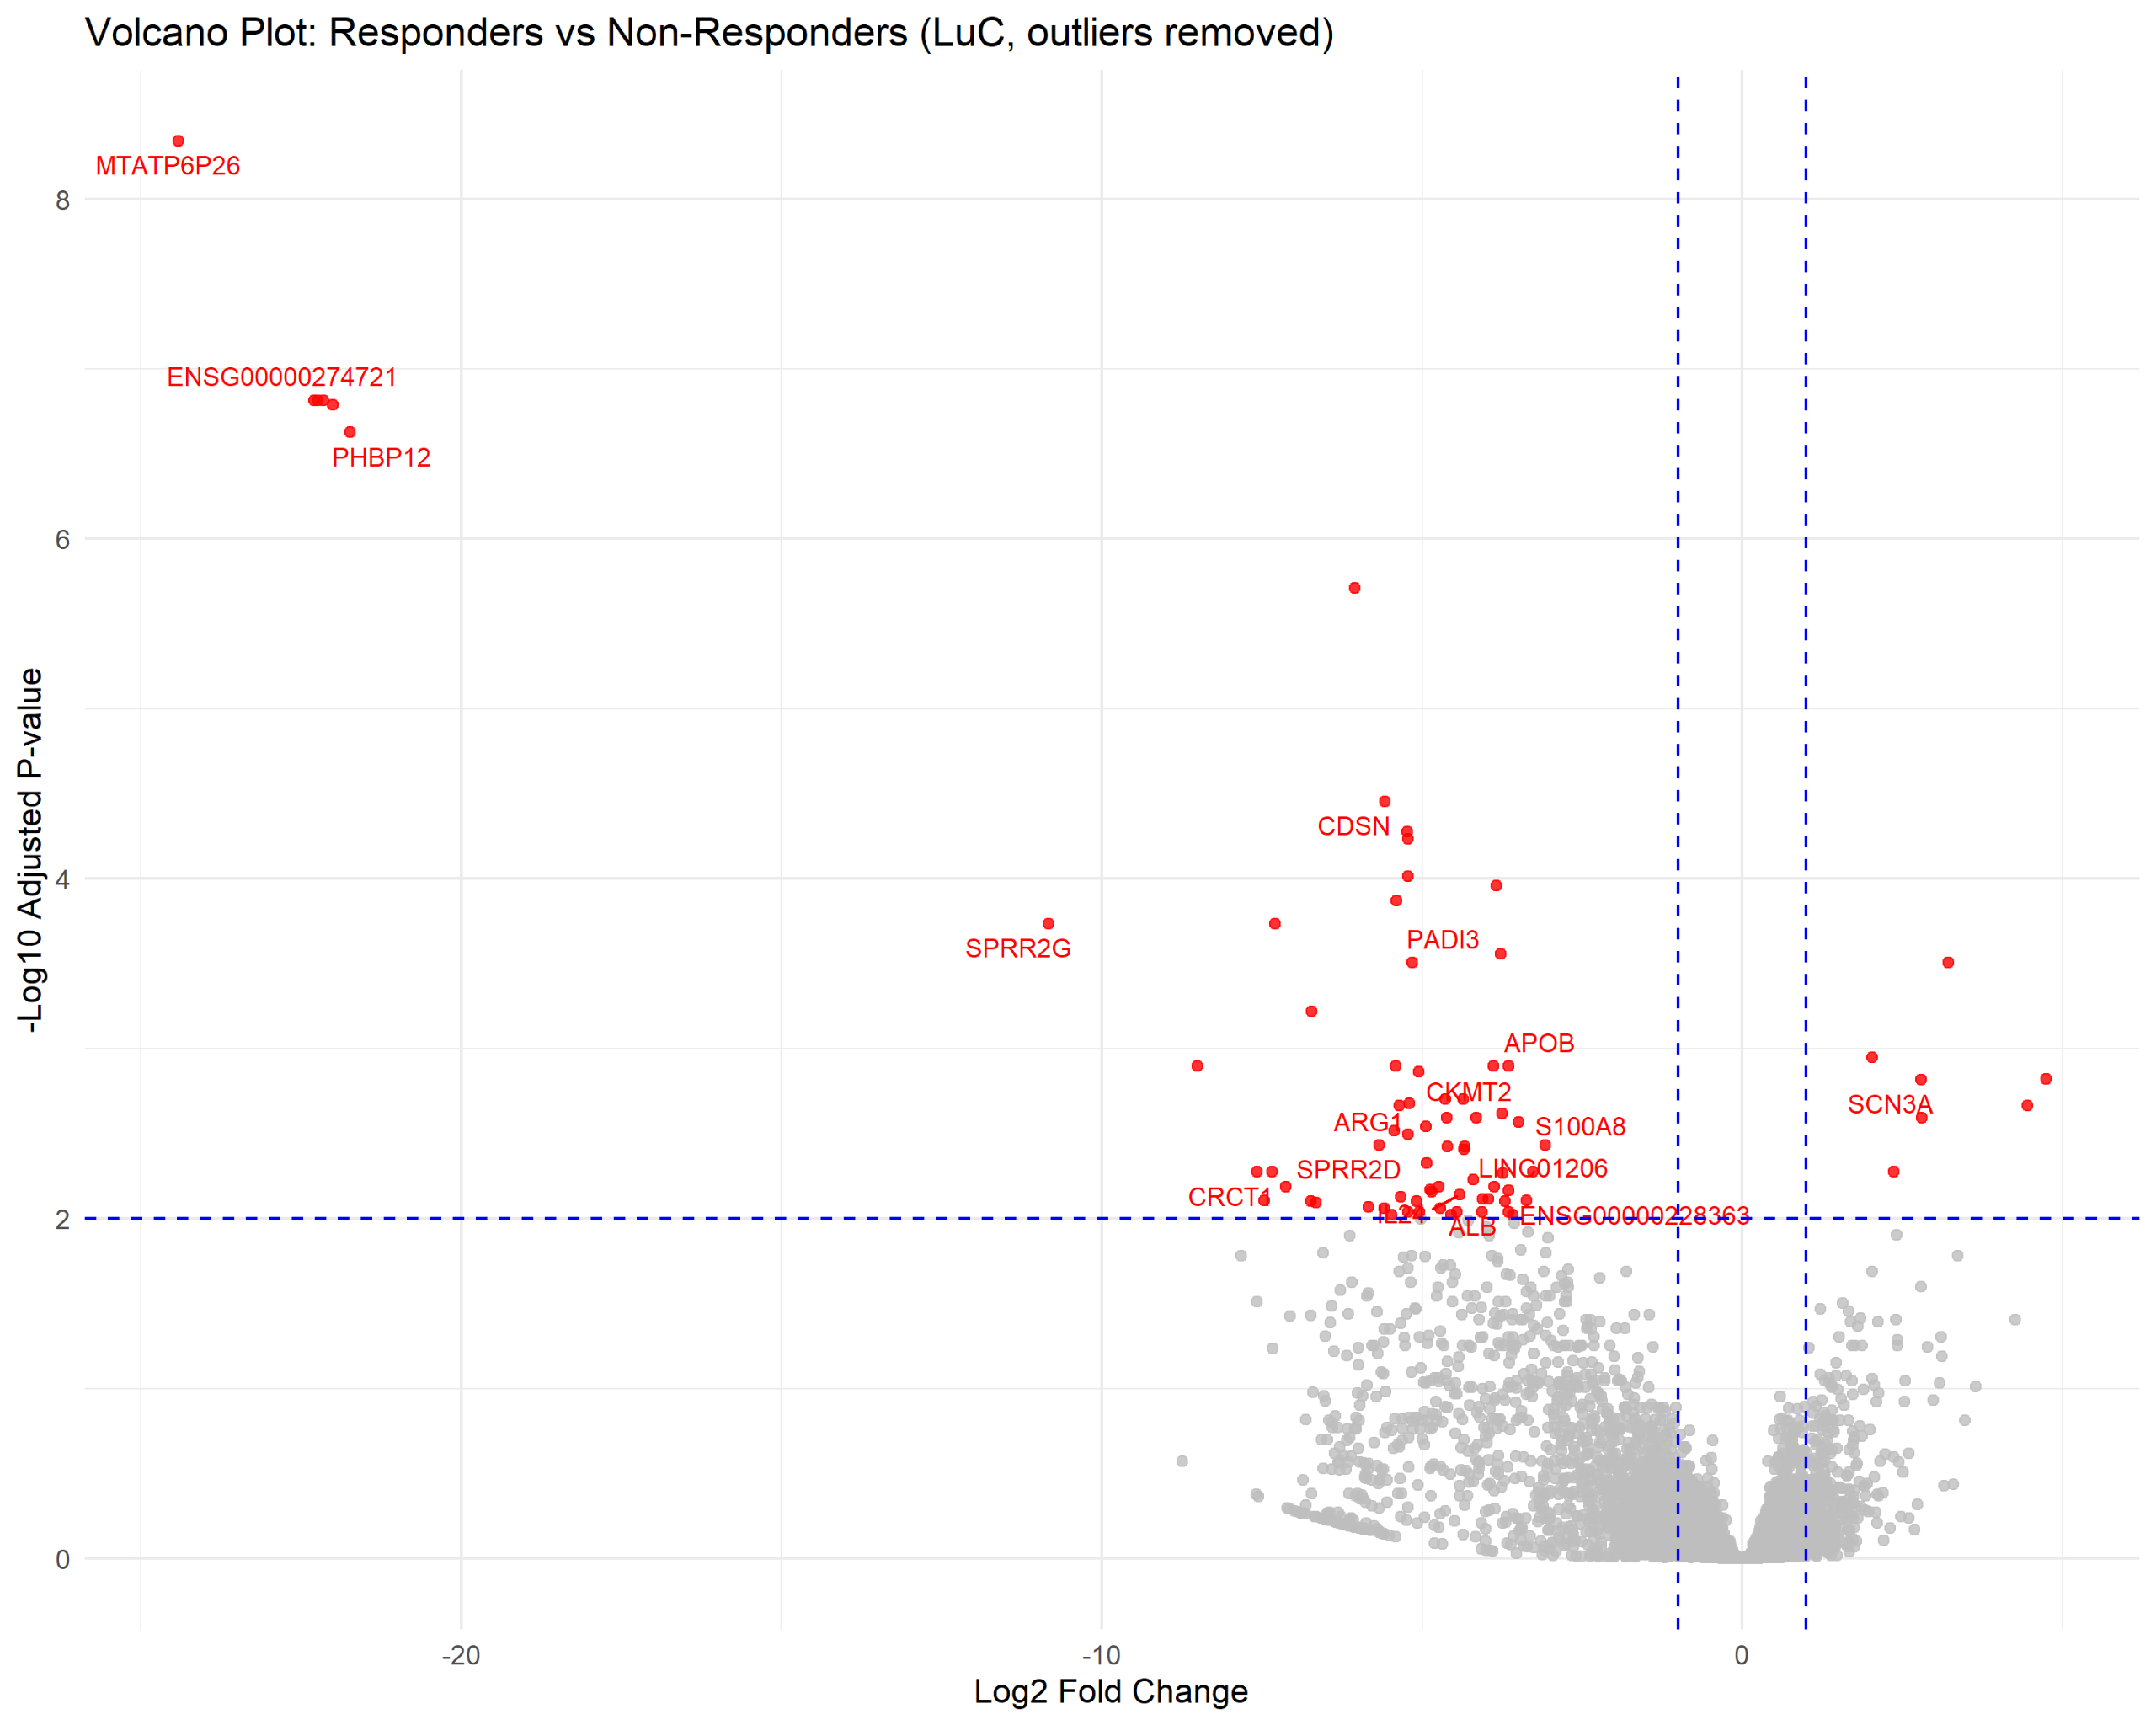

Большинство значимых генов имеют изменения экспрессии в диапазоне |log2FC| от 1 до 7, при этом часть генов демонстрирует очень сильные изменения (log2FC > 5).

На графике видно, что большинство красных точек расположены слева (отрицательные значения log2FC). Это соответствует генам с пониженной экспрессией у Responders по сравнению с Non-Responders. Данное наблюдение согласуется с общей статистикой `summary(res)`, где при `padj < 0.1` количество пониженных генов (305) значительно превышает число повышенных (45).





### **6. Выводы по части 1**

- **DESeq2** выявил **79 генов**, достоверно дифференциально экспрессированных между Responders (R) и Non-Responders (NR) при порогах `padj < 0.01` и `|log2FC| > 1`.
- На **volcano plot** большинство значимых генов расположены в левой полуплоскости (отрицательные `log2FC`), что указывает на пониженную экспрессию этих генов у Responders по сравнению с Non-Responders.
- При более мягком пороге `padj < 0.1` (без фильтрации по `log2FC`) соотношение пониженных генов к повышенным составляет 305 против 45, что также подтверждает общее подавление экспрессии в группе Responders.
- Отсутствие выбросов по Cook’s distance и корректная нормализация данных свидетельствуют о надёжности полученных результатов.
- Полученный список из 79 генов может быть использован для последующего анализа биологических путей, идентификации потенциальных биомаркеров ответа на иммунотерапию и валидации экспериментальными методами (ПЦР, вестерн-блот).

## **Часть 2. LIMMA анализ**

### **1. Обоснование выбора LIMMA**

LIMMA (Linear Models for Microarray Data) изначально разработан для анализа микрочипов, но успешно применяется и для RNA-seq данных после лог-трансформации (logCPM). В данном задании LIMMA используется как альтернативный метод для тех же данных LuC (после удаления выбросов) с целью:

- Сравнения результатов с DESeq2.
- Оценки влияния порога log₂FC на количество выявляемых дифференциально экспрессированных генов.
- Использования линейных моделей с модерацией t-статистики, что даёт устойчивые оценки при малых выборках.

Уровень значимости принят как **raw p-value < 0.05** (без множественной коррекции), чтобы оценить именно эффект порога logFC, а не влияние метода коррекции.

### **2. Количество значимых генов при разных порогах logFC**

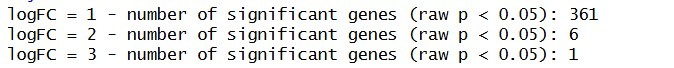

График зависимости числа генов от порога:

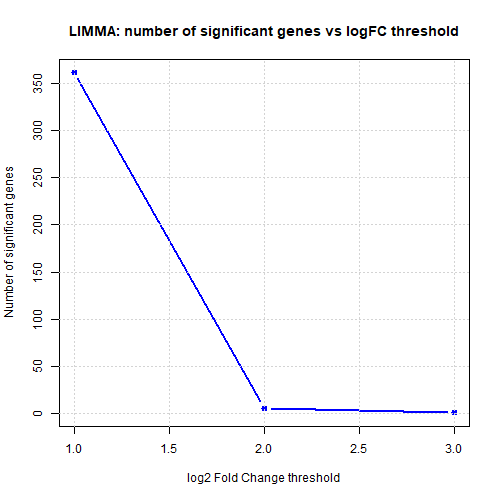

### **3. Volcano plots для каждого порога**

Визуализация дифференциальной экспрессии для трёх порогов logFC (1, 2, 3) представлена на volcano plots. Красным отмечены гены, удовлетворяющие критериям: raw p-value < 0.05 и |logFC| > заданного порога.

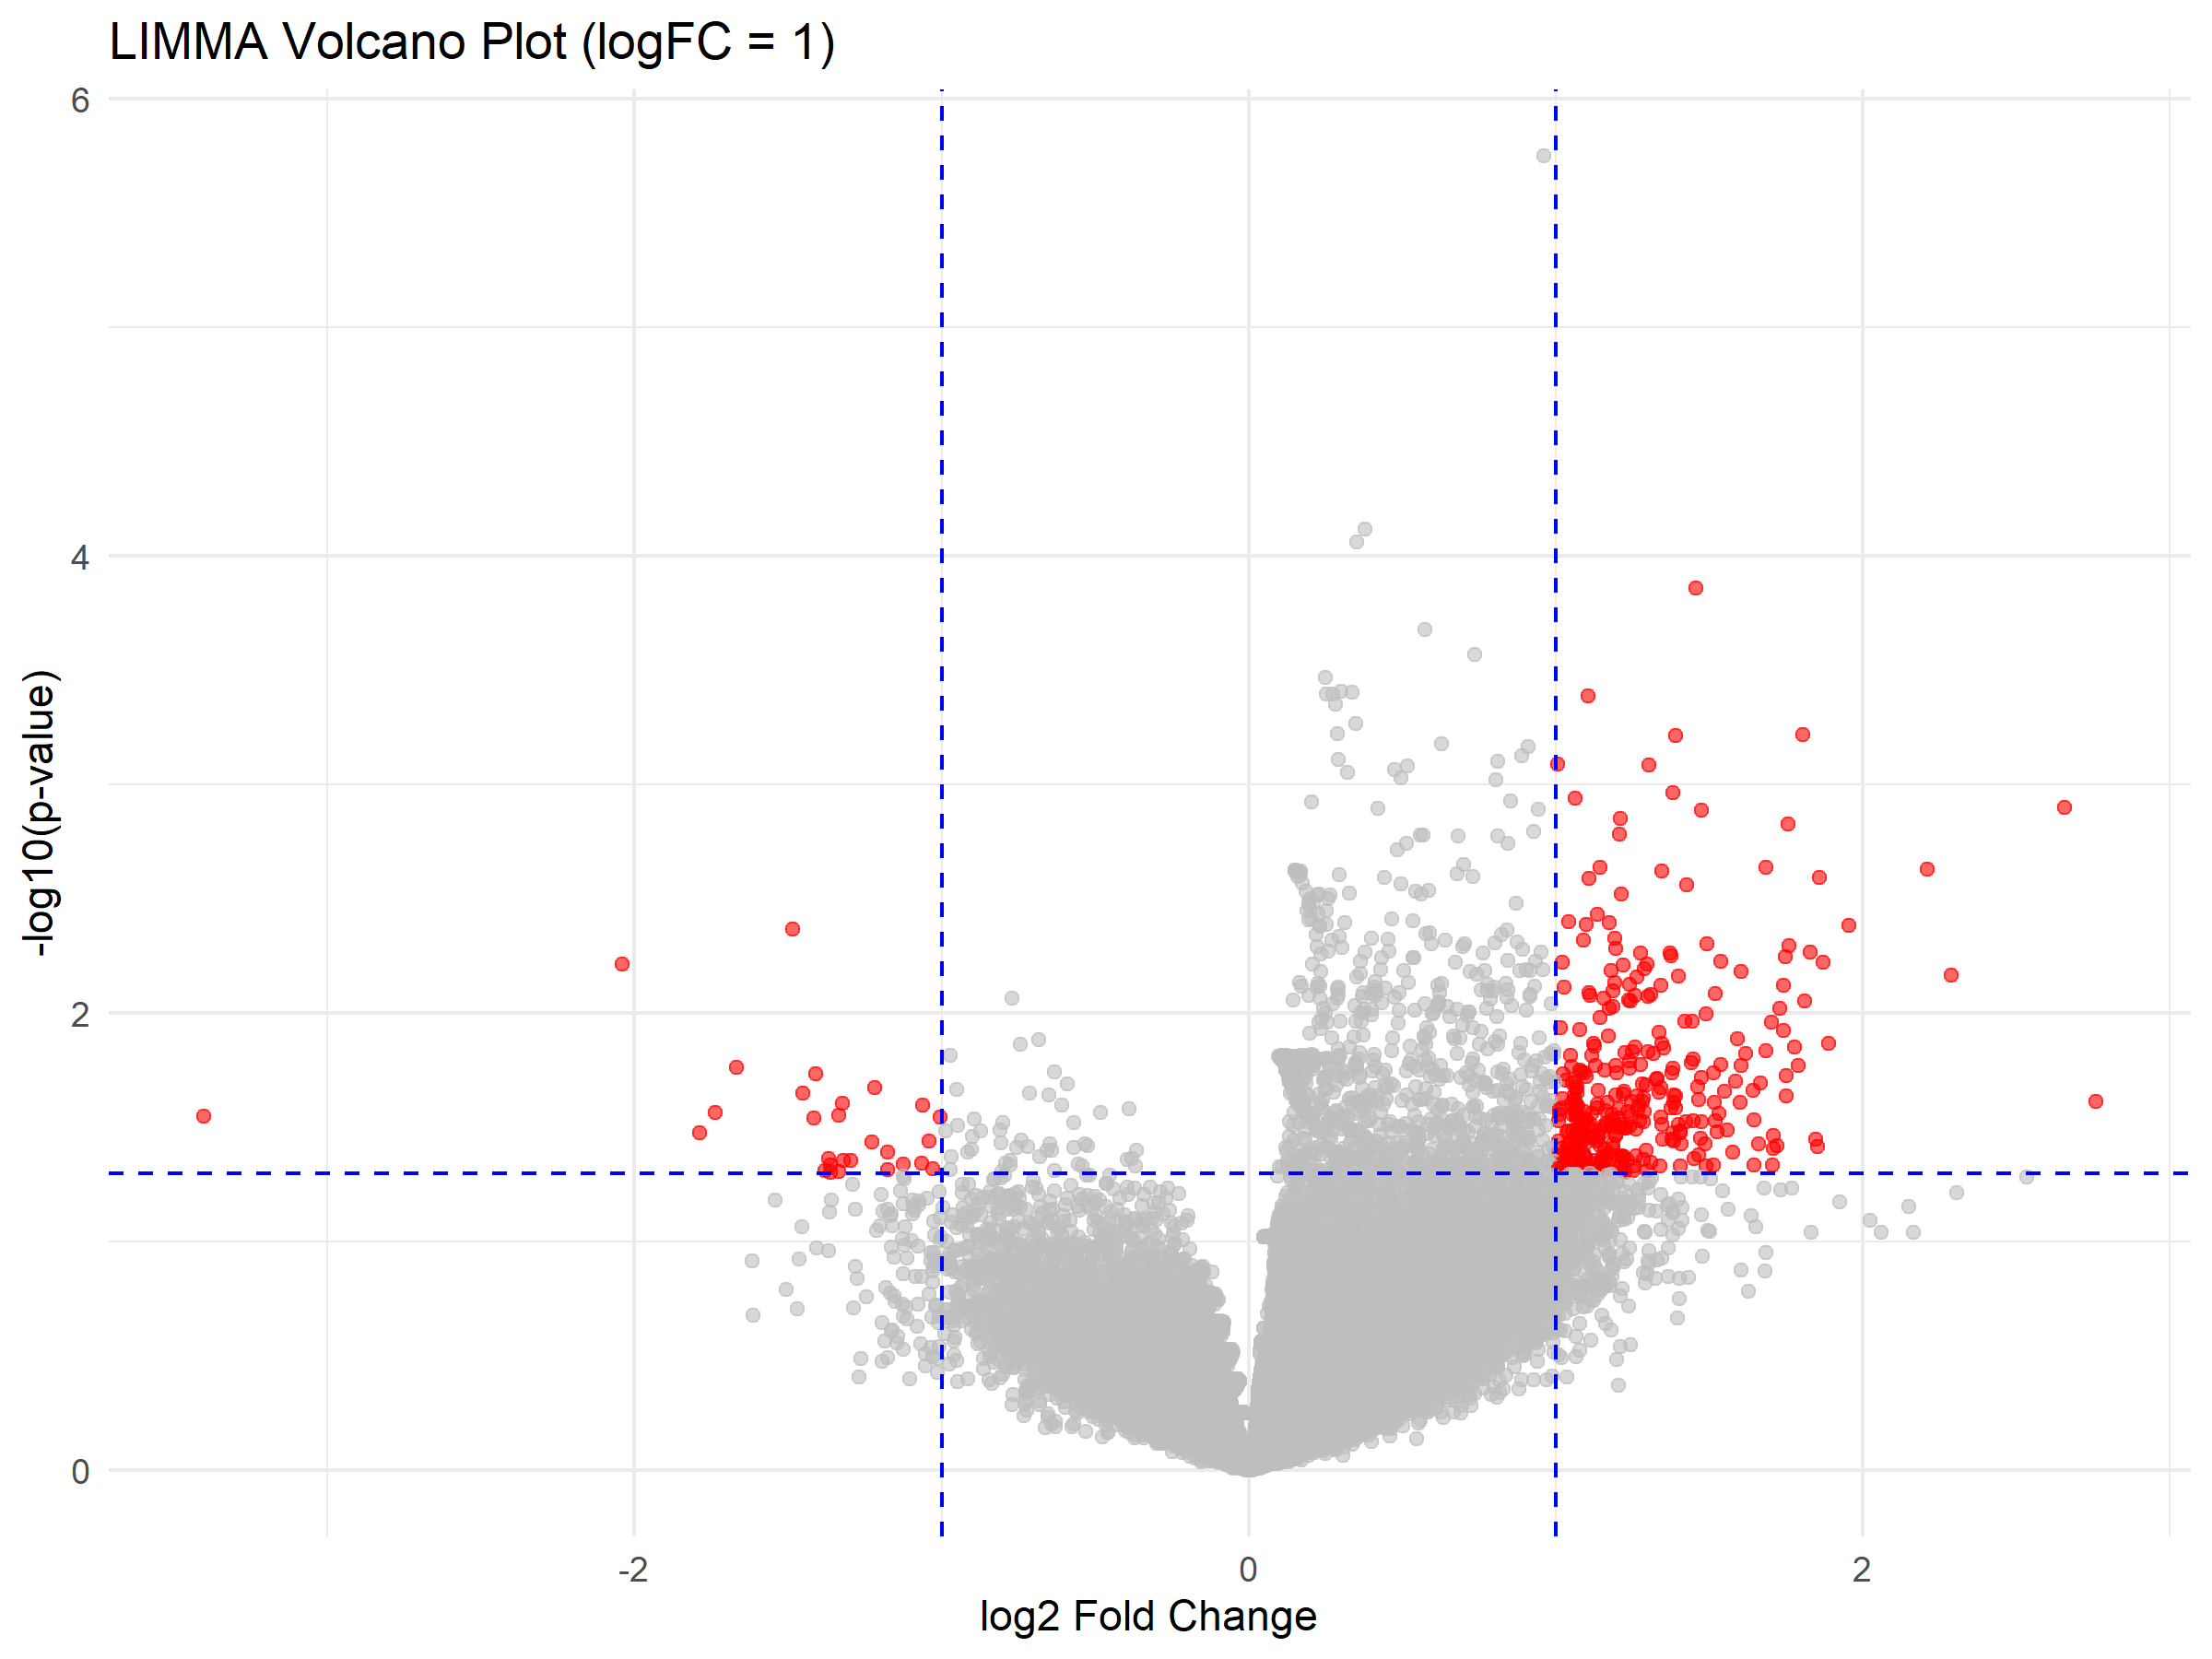

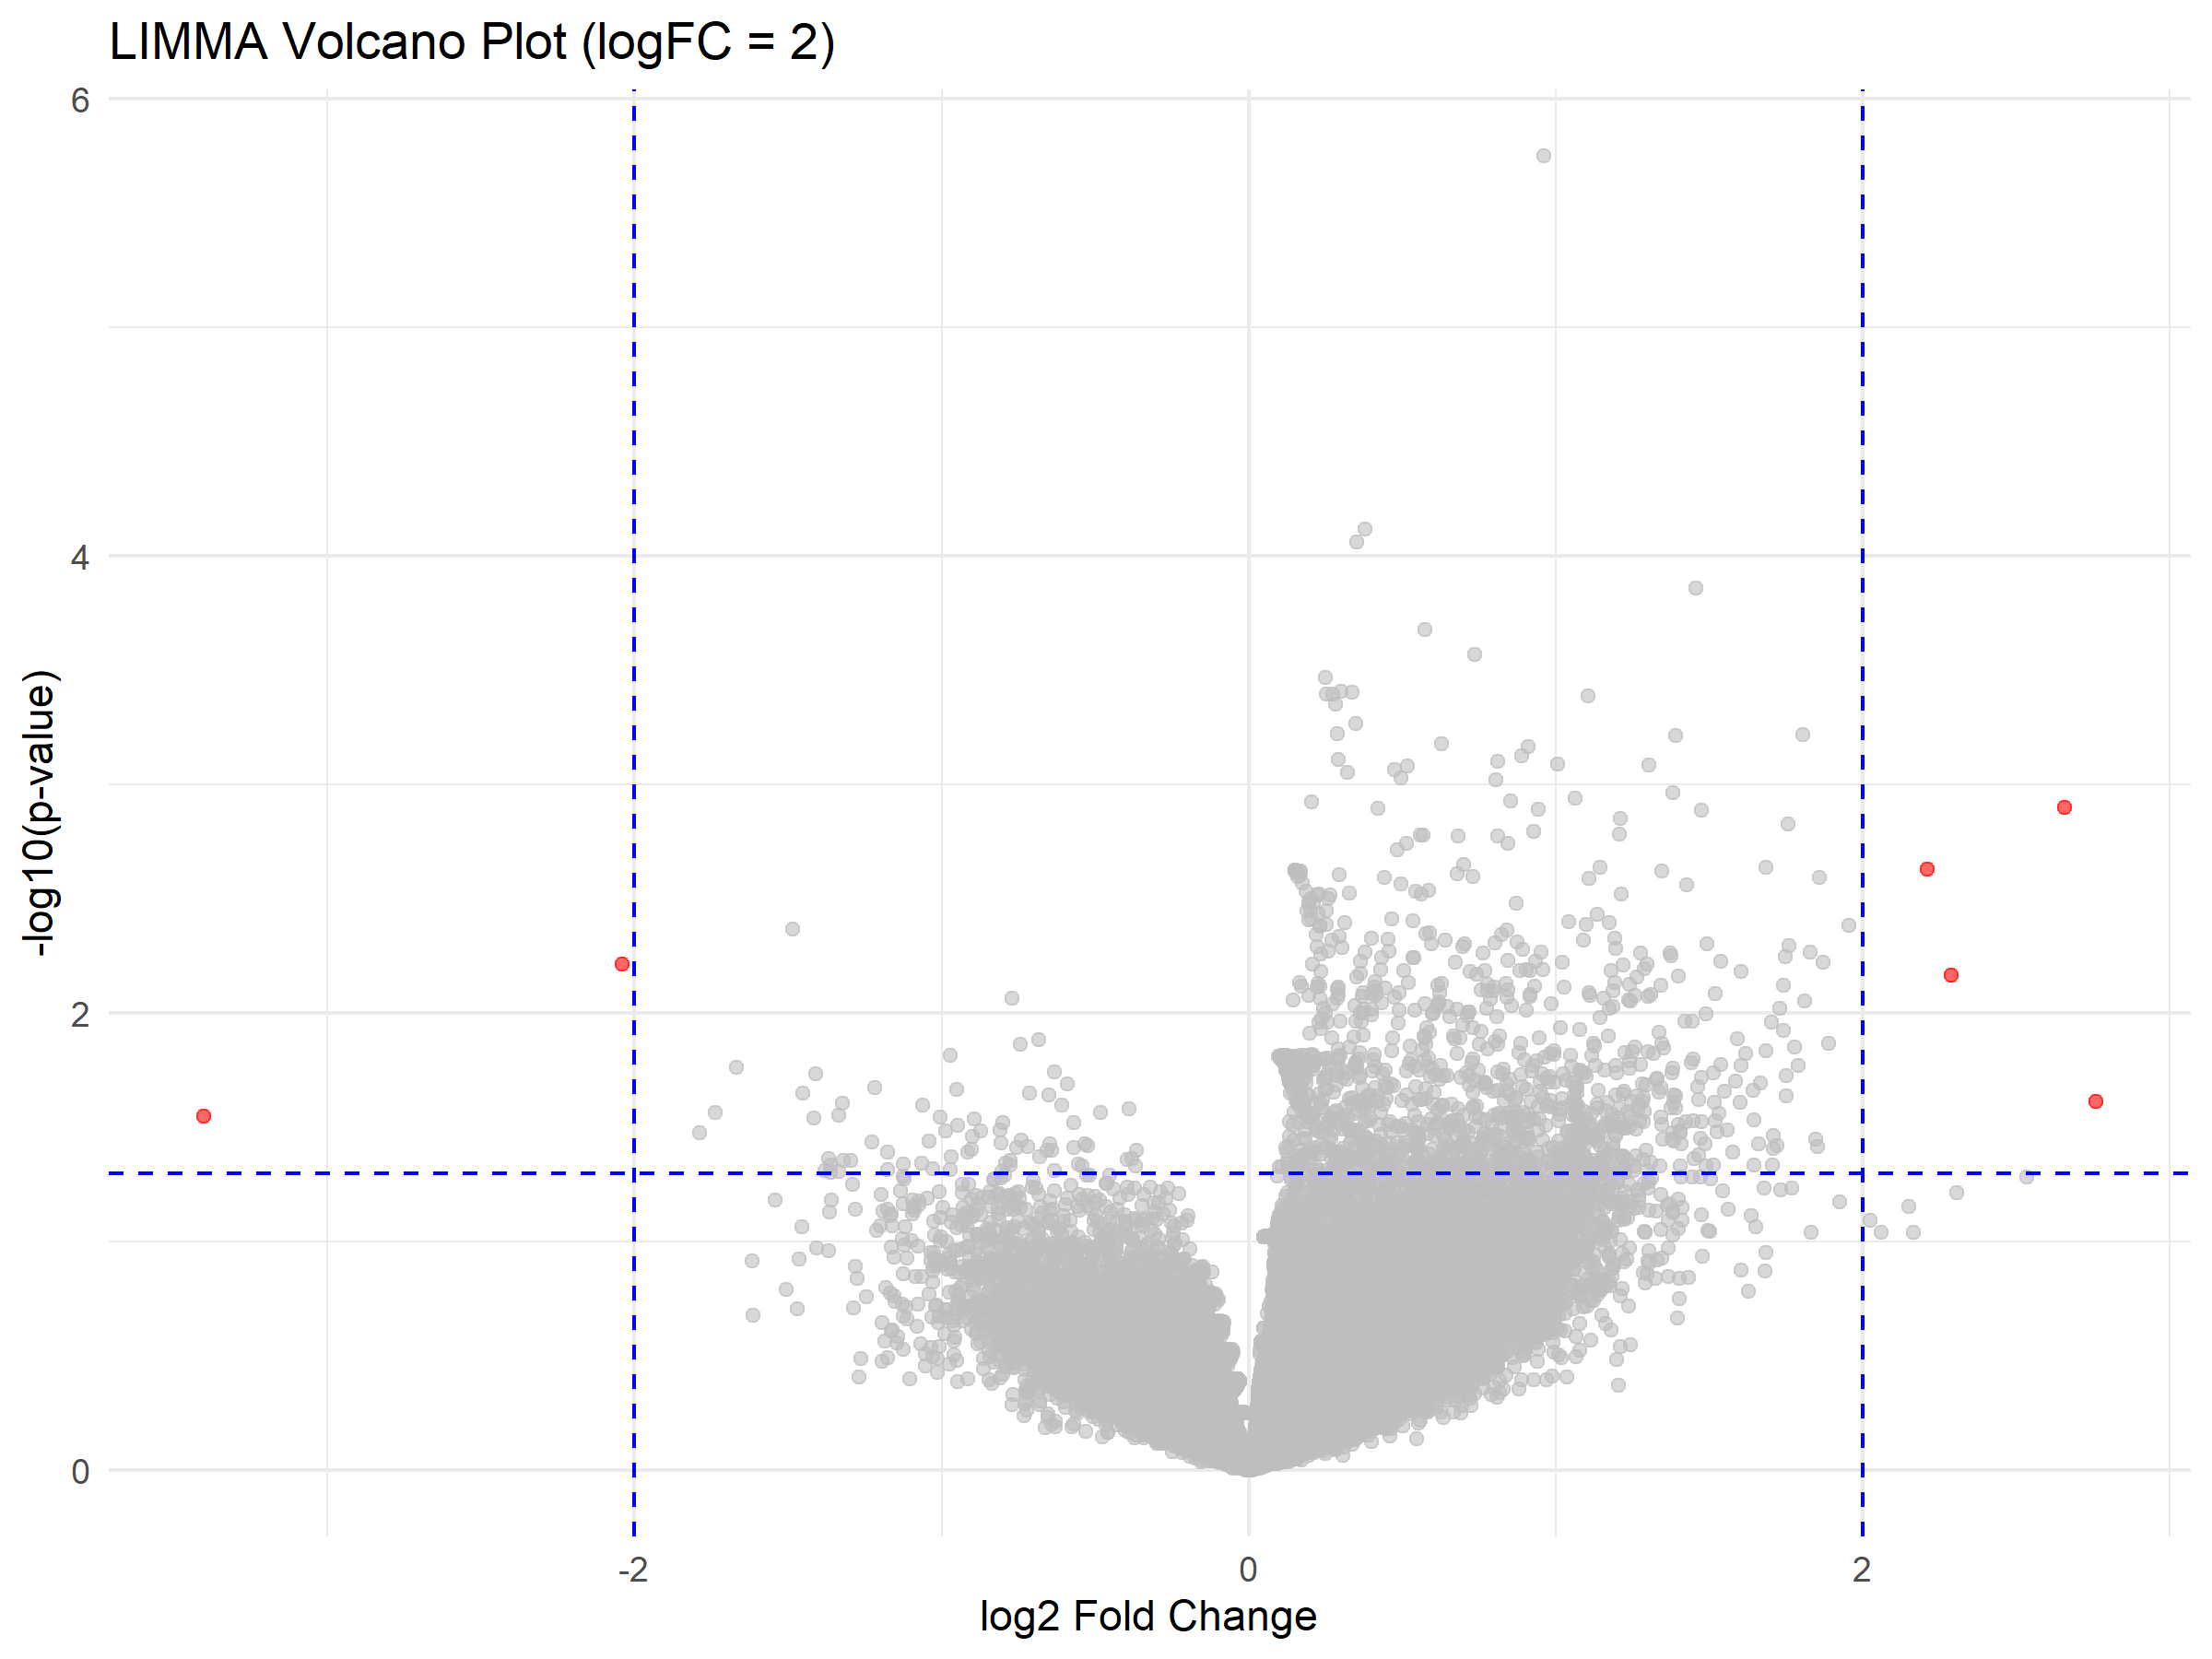

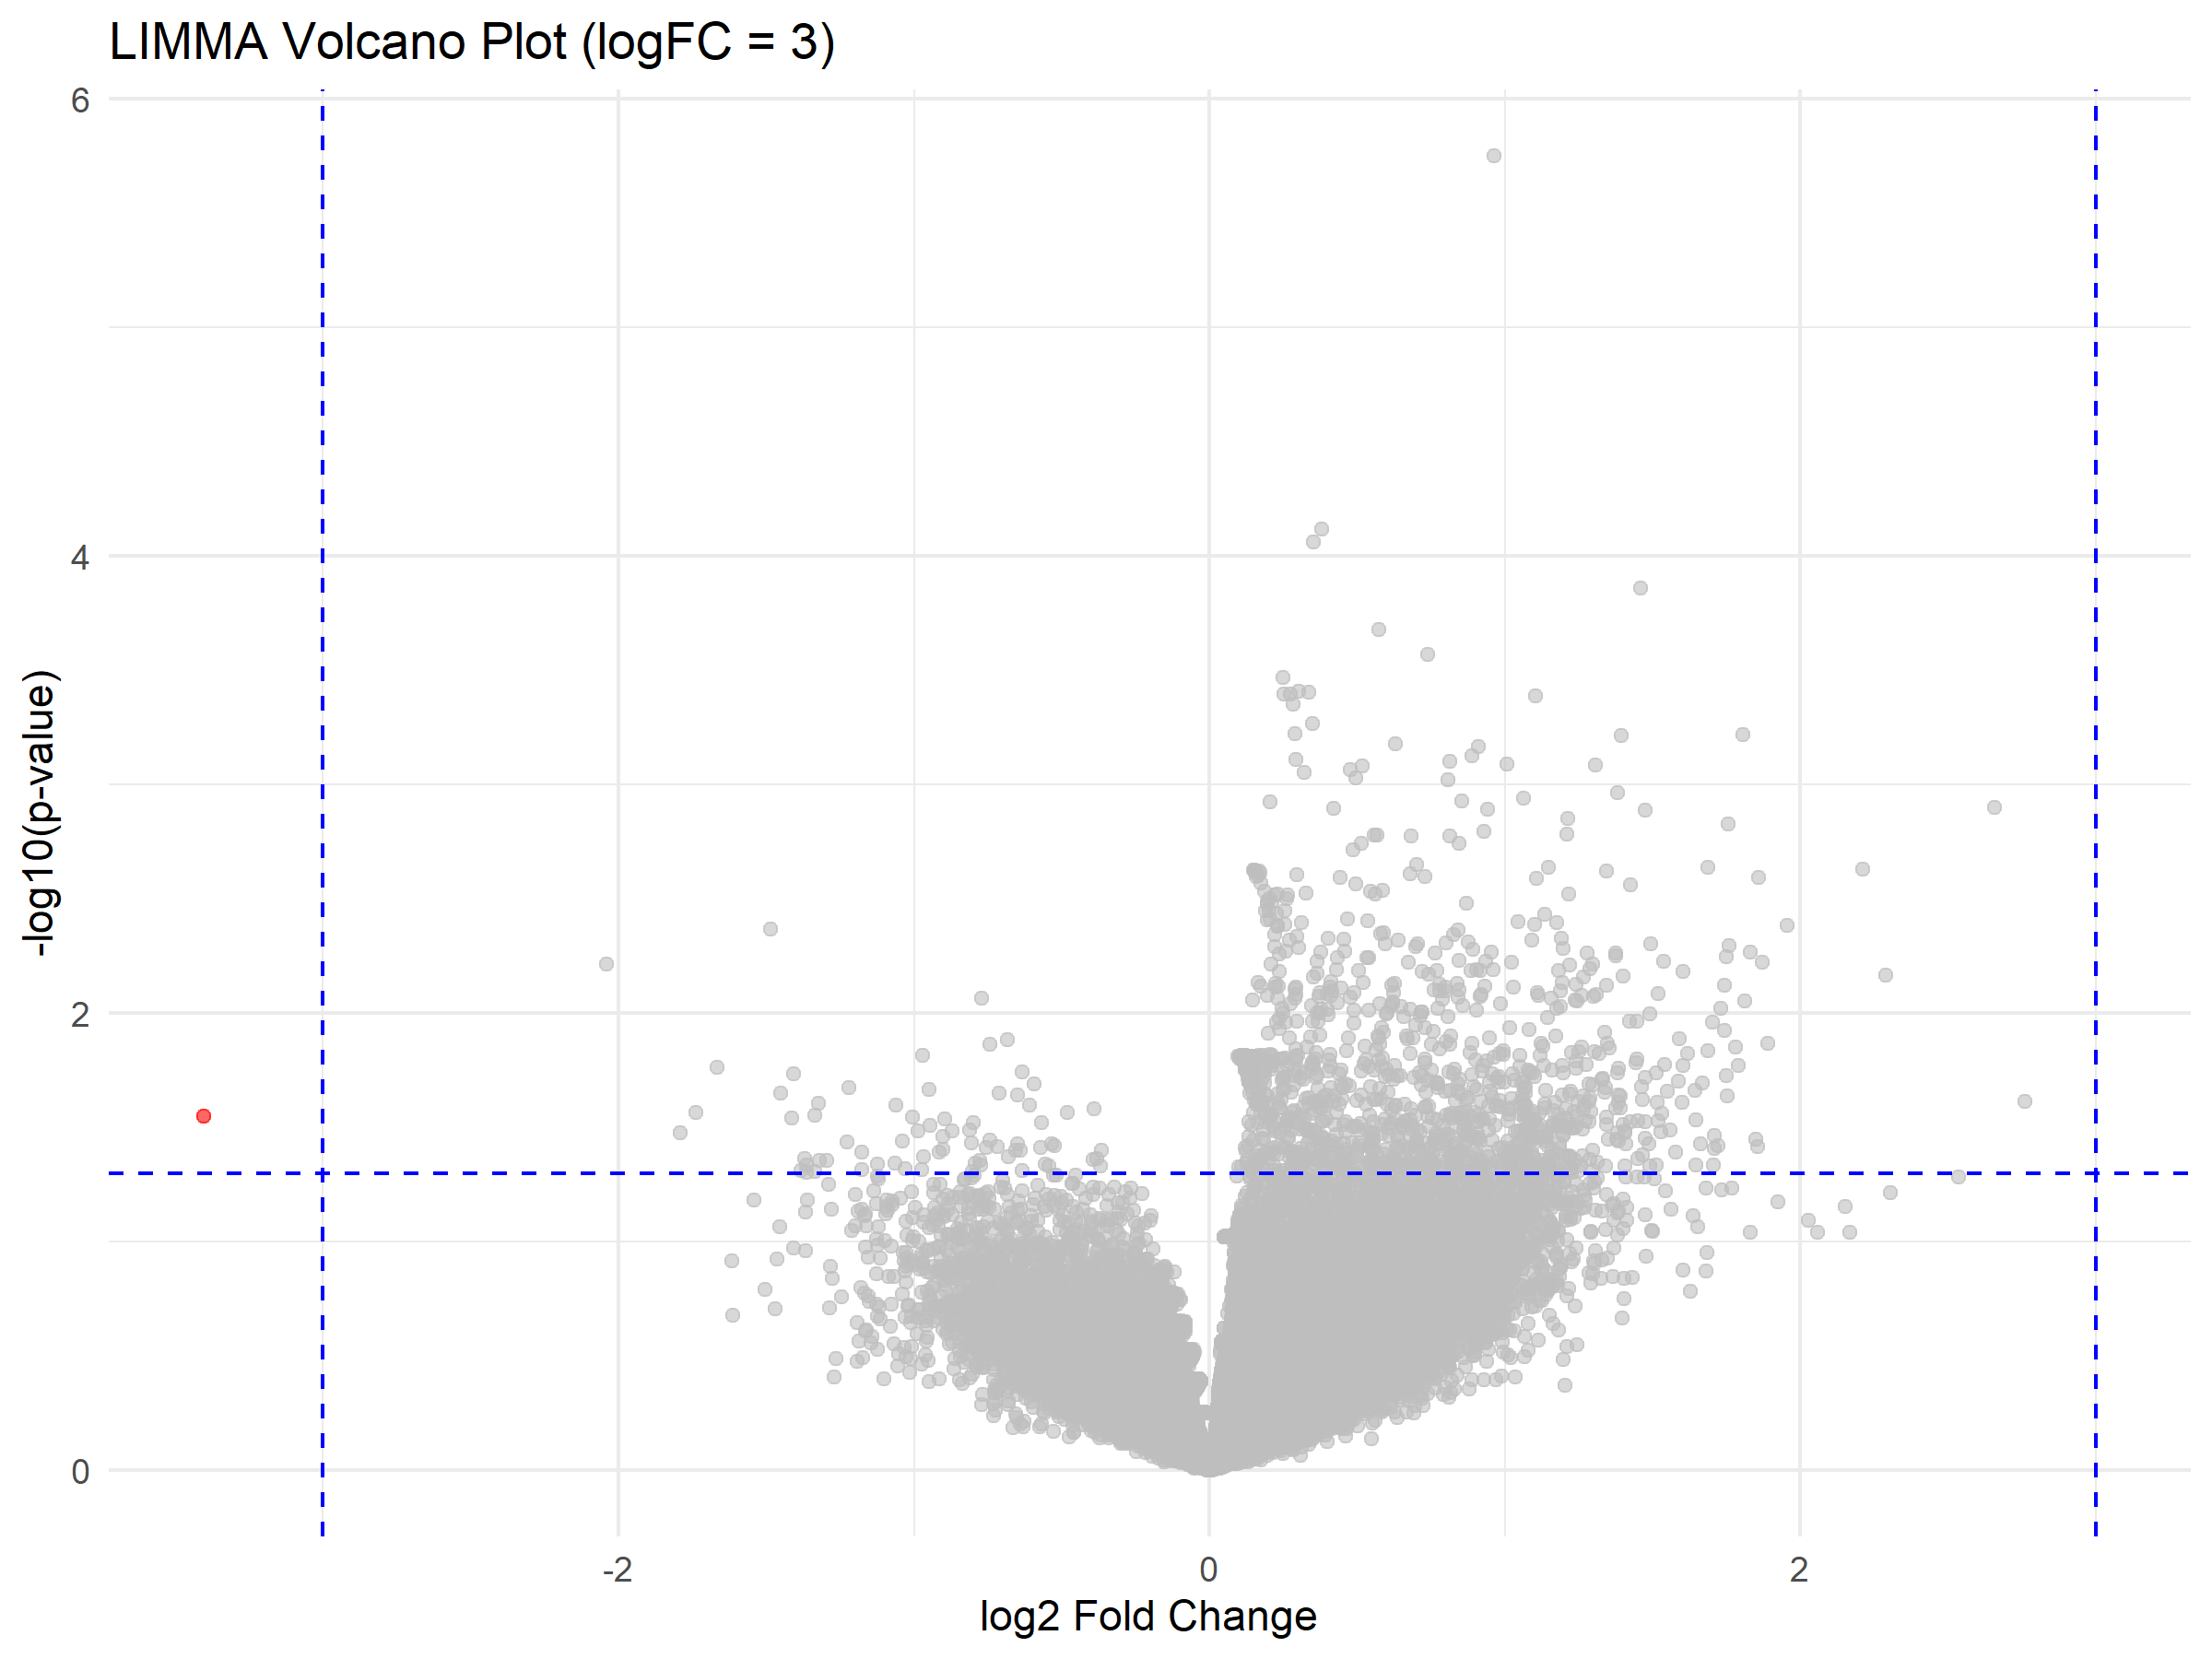

- **logFC = 1** – множество красных точек как слева, так и справа; много генов с малыми изменениями.
- **logFC = 2** – остаётся 6 генов, все с высокой статистической значимостью.
- **logFC = 3** – только 1 ген, что чрезмерно строго.

### **4. Выбор оптимального порога logFC**

- **logFC = 1** даёт 361 ген. Среди них присутствуют гены с изменениями менее чем в 2 раза, что увеличивает вероятность ложноположительных результатов и затрудняет биологическую интерпретацию.
- **logFC = 2** выделяет 6 генов, изменённых в 4 и более раз. Это сильные кандидаты, удобные для дальнейшей валидации (ПЦР, вестерн-блот).
- **logFC = 3** оставляет 1 ген – слишком жёсткий порог, риск пропустить важные гены с умеренным, но биологически значимым эффектом.

**Вывод:** оптимальным является порог **logFC = 2**, так как он обеспечивает баланс между чувствительностью (не теряем важные гены) и специфичностью (отсеиваем ложные срабатывания).

### **5. Таблица с тремя столбцами значимости**

В соответствии с заданием, для результатов LIMMA добавлены три дополнительных столбца, указывающих, является ли ген значимым при пороге logFC = 1, 2 или 3 (условие: raw p-value < 0.05 и |logFC| > порога).

**Пример первых шести строк таблицы `LIMMA_results_LuC_all.csv`:**

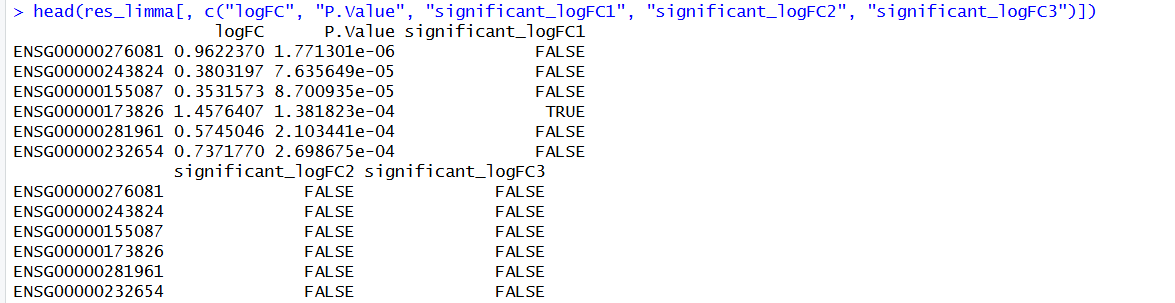

При порогах logFC = 2 и logFC = 3 значимые гены (6 и 1 соответственно) не попали в этот фрагмент, но они присутствуют в полной версии.

### **6. Выводы по части 2**

- LIMMA подтверждает, что при увеличении порога logFC число значимых генов резко падает (361 → 6 → 1).
- Выбран порог **logFC = 2**, дающий 6 генов с сильным изменением экспрессии (в 4 и более раза).
- Создана таблица с тремя столбцами значимости, что позволяет легко фильтровать гены для каждого порога.
- Несмотря на различия в количестве генов, оба метода (DESeq2 и LIMMA) указывают на преобладание пониженной экспрессии у Responders.
- Для окончательного списка дифференциально экспрессированных генов рекомендуется опираться на **DESeq2** как специализированный для RNA-seq инструмент, а результаты LIMMA использовать для кросс-валидации.